# Compare supervised baselines: ViT vs ResNet50 (HyperKvasir)

Purpose: load the saved metrics from the ViT and ResNet50 fine-tuning runs in this folder and present side-by-side comparisons (overall metrics + per-class F1).

Results shown:
- Overall accuracy / macro-F1 / weighted-F1 for each model.
- Per-class F1 bar chart (side-by-side bars).
- Top/bottom classes by F1 for each model.

How to read the plots/tables:
- Overall table: higher is better; macro-F1 treats all classes equally, weighted-F1 accounts for class support.
- Per-class bar chart: each class has two bars (ViT blue, ResNet orange); tall bars mean better F1 on that class.
- Top/bottom tables: classes where each model excels or struggles; look for consistent gains/losses across models.


In [1]:
import json
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

# Locate project root (folder containing 0_dataset_prep)
def find_dataset_root() -> Path:
    start = Path.cwd().resolve()
    for p in [start] + list(start.parents):
        if (p / "0_dataset_prep").exists():
            return p
    raise RuntimeError(f"Could not locate dataset root containing '0_dataset_prep'. cwd={start}")

DATA_ROOT = find_dataset_root()
OUT_DIR = DATA_ROOT / "2_supervised_finetuning" / "out"
VIT_METRICS = OUT_DIR / "metrics_vit.json"
RESNET_METRICS = OUT_DIR / "metrics_resnet.json"

print("DATA_ROOT:", DATA_ROOT)
print("OUT_DIR:", OUT_DIR)
print("ViT metrics:", VIT_METRICS)
print("ResNet metrics:", RESNET_METRICS)


DATA_ROOT: /home/aristotle/Desktop/rag-vqa-medical/Prototyping_reformat/DatasetAnalysis/HyperKvasir
OUT_DIR: /home/aristotle/Desktop/rag-vqa-medical/Prototyping_reformat/DatasetAnalysis/HyperKvasir/2_supervised_finetuning/out
ViT metrics: /home/aristotle/Desktop/rag-vqa-medical/Prototyping_reformat/DatasetAnalysis/HyperKvasir/2_supervised_finetuning/out/metrics_vit.json
ResNet metrics: /home/aristotle/Desktop/rag-vqa-medical/Prototyping_reformat/DatasetAnalysis/HyperKvasir/2_supervised_finetuning/out/metrics_resnet.json


In [2]:
# Load metrics
with open(VIT_METRICS) as f:
    vit = json.load(f)
with open(RESNET_METRICS) as f:
    res = json.load(f)

# Extract overall
overall = pd.DataFrame([
    {
        "model": "ViT",
        "accuracy": vit.get("accuracy"),
        "macro_f1": vit.get("macro avg", {}).get("f1-score"),
        "weighted_f1": vit.get("weighted avg", {}).get("f1-score"),
    },
    {
        "model": "ResNet50",
        "accuracy": res.get("accuracy"),
        "macro_f1": res.get("macro avg", {}).get("f1-score"),
        "weighted_f1": res.get("weighted avg", {}).get("f1-score"),
    },
])
print("Overall metrics (higher is better):")
display(overall)


Overall metrics (higher is better):


,model,accuracy,macro_f1,weighted_f1
0,ViT,0.871362,0.524242,0.855874
1,ResNet50,0.878873,0.594305,0.878600


In [3]:
# Per-class F1
vit_df = pd.DataFrame(vit).T
res_df = pd.DataFrame(res).T

# Drop aggregate rows
for agg in ["accuracy", "macro avg", "weighted avg"]:
    vit_df = vit_df.drop(agg, errors='ignore')
    res_df = res_df.drop(agg, errors='ignore')

per_class = pd.DataFrame({
    "vit_f1": vit_df["f1-score"],
    "resnet_f1": res_df["f1-score"],
    "vit_support": vit_df["support"],
    "resnet_support": res_df["support"],
}).sort_index()

print("Per-class F1 head():")
display(per_class.head())


Per-class F1 head():


,vit_f1,resnet_f1,vit_support,resnet_support
barretts,0.000000,0.285714,4.0,4.0
barretts-short-segment,0.000000,0.181818,5.0,5.0
bbps-0-1,0.969231,0.976744,65.0,65.0
bbps-2-3,0.968889,0.964286,115.0,115.0
cecum,0.980392,0.980392,101.0,101.0


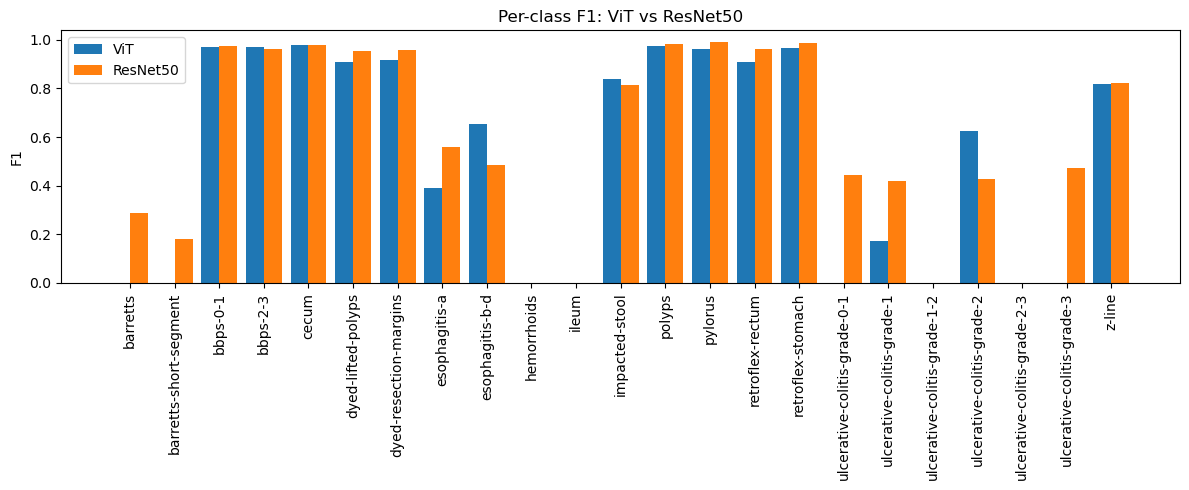

In [4]:
# Bar chart: per-class F1 (side-by-side)
fig, ax = plt.subplots(figsize=(12, 5))
idx = per_class.index
x = range(len(idx))
width = 0.4
ax.bar([i - width/2 for i in x], per_class["vit_f1"], width=width, label="ViT")
ax.bar([i + width/2 for i in x], per_class["resnet_f1"], width=width, label="ResNet50")
ax.set_xticks(list(x))
ax.set_xticklabels(idx, rotation=90)
ax.set_ylabel("F1")
ax.set_title("Per-class F1: ViT vs ResNet50")
ax.legend()
plt.tight_layout()
plt.show()


In [5]:
# Top/bottom classes by F1
vit_top = per_class.sort_values("vit_f1", ascending=False).head(5)
vit_bot = per_class.sort_values("vit_f1", ascending=True).head(5)
res_top = per_class.sort_values("resnet_f1", ascending=False).head(5)
res_bot = per_class.sort_values("resnet_f1", ascending=True).head(5)

print("ViT top-5 classes (F1):")
display(vit_top[["vit_f1", "resnet_f1"]])
print("ViT bottom-5 classes (F1):")
display(vit_bot[["vit_f1", "resnet_f1"]])

print("ResNet50 top-5 classes (F1):")
display(res_top[["vit_f1", "resnet_f1"]])
print("ResNet50 bottom-5 classes (F1):")
display(res_bot[["vit_f1", "resnet_f1"]])


ViT top-5 classes (F1):


,vit_f1,resnet_f1
cecum,0.980392,0.980392
polyps,0.975369,0.985222
bbps-0-1,0.969231,0.976744
bbps-2-3,0.968889,0.964286
retroflex-stomach,0.968153,0.987013


ViT bottom-5 classes (F1):


,vit_f1,resnet_f1
barretts,0.0,0.285714
barretts-short-segment,0.0,0.181818
ulcerative-colitis-grade-2-3,0.0,0.000000
ulcerative-colitis-grade-1-2,0.0,0.000000
ulcerative-colitis-grade-0-1,0.0,0.444444


ResNet50 top-5 classes (F1):


,vit_f1,resnet_f1
pylorus,0.964103,0.990000
retroflex-stomach,0.968153,0.987013
polyps,0.975369,0.985222
cecum,0.980392,0.980392
bbps-0-1,0.969231,0.976744


ResNet50 bottom-5 classes (F1):


,vit_f1,resnet_f1
ulcerative-colitis-grade-2-3,0.0,0.000000
ulcerative-colitis-grade-1-2,0.0,0.000000
hemorrhoids,0.0,0.000000
ileum,0.0,0.000000
barretts-short-segment,0.0,0.181818


## How to interpret
- If one model consistently has higher bars/F1 across classes, it’s stronger overall.
- Look at bottom-5 tables to see which classes need attention (augmentation, loss reweighting, more data).
- If a class flips (ViT better on some, ResNet on others), consider ensembling or targeted augmentation.


In [1]:
# Thesis-useful summary (auto-generated)
import json
from pathlib import Path
import pandas as pd

def _find_root():
    start = Path.cwd().resolve()
    for p in [start] + list(start.parents):
        if (p / '0_dataset_prep').exists():
            return p
    return None

def _load_metrics(path):
    with open(path) as f:
        return json.load(f)

def _print_overall(name, report):
    print(f"{name} accuracy: {report['accuracy']:.5f}")
    print(f"{name} macro F1: {report['macro avg']['f1-score']:.5f}")
    print(f"{name} weighted F1: {report['weighted avg']['f1-score']:.5f}")

def _print_uc(report, label):
    uc_keys = [k for k in report.keys() if k.startswith('ulcerative-colitis-grade-')]
    print(f"{label} UC grade per-class (precision, recall, f1, support):")
    if not uc_keys:
        print('  No UC grade classes found.')
        return
    for k in sorted(uc_keys):
        v = report[k]
        print(f"  {k}: P={v['precision']:.3f}, R={v['recall']:.3f}, F1={v['f1-score']:.3f}, n={int(v['support'])}")

def _top_bottom(report, k=5):
    rows = []
    for label, v in report.items():
        if label in ('accuracy', 'macro avg', 'weighted avg'):
            continue
        rows.append((label, v['f1-score'], v['precision'], v['recall'], v['support']))
    rows = sorted(rows, key=lambda x: x[1])
    worst = rows[:k]
    best = rows[-k:]
    return worst, best

root = _find_root()
if root is None:
    print('Could not locate dataset root for summary.')
else:
    out_dir = root / '2_supervised_finetuning' / 'out'
    vit_path = out_dir / 'metrics_vit.json'
    res_path = out_dir / 'metrics_resnet.json'
    if not vit_path.exists() or not res_path.exists():
        print('Metrics not found. Run the fine-tuning notebooks first to generate metrics.')
    else:
        vit = _load_metrics(vit_path)
        res = _load_metrics(res_path)
        print('=== Thesis-Useful Summary: ViT vs ResNet50 (Supervised Fine-tuning) ===')
        print('Overall metrics:')
        _print_overall('ViT', vit)
        _print_overall('ResNet50', res)
        print('---')
        _print_uc(vit, 'ViT')
        print('---')
        _print_uc(res, 'ResNet50')
        print('---')
        vit_worst, vit_best = _top_bottom(vit, k=5)
        res_worst, res_best = _top_bottom(res, k=5)
        print('ViT worst 5 classes by F1:')
        for label, f1, p, r, s in vit_worst:
            print(f"  {label}: F1={f1:.3f}, P={p:.3f}, R={r:.3f}, n={int(s)}")
        print('ViT best 5 classes by F1:')
        for label, f1, p, r, s in vit_best:
            print(f"  {label}: F1={f1:.3f}, P={p:.3f}, R={r:.3f}, n={int(s)}")
        print('ResNet50 worst 5 classes by F1:')
        for label, f1, p, r, s in res_worst:
            print(f"  {label}: F1={f1:.3f}, P={p:.3f}, R={r:.3f}, n={int(s)}")
        print('ResNet50 best 5 classes by F1:')
        for label, f1, p, r, s in res_best:
            print(f"  {label}: F1={f1:.3f}, P={p:.3f}, R={r:.3f}, n={int(s)}")


=== Thesis-Useful Summary: ViT vs ResNet50 (Supervised Fine-tuning) ===
Overall metrics:
ViT accuracy: 0.87136
ViT macro F1: 0.52424
ViT weighted F1: 0.85587
ResNet50 accuracy: 0.87887
ResNet50 macro F1: 0.59431
ResNet50 weighted F1: 0.87860
---
ViT UC grade per-class (precision, recall, f1, support):
  ulcerative-colitis-grade-0-1: P=0.000, R=0.000, F1=0.000, n=3
  ulcerative-colitis-grade-1: P=0.667, R=0.100, F1=0.174, n=20
  ulcerative-colitis-grade-1-2: P=0.000, R=0.000, F1=0.000, n=1
  ulcerative-colitis-grade-2: P=0.487, R=0.864, F1=0.623, n=44
  ulcerative-colitis-grade-2-3: P=0.000, R=0.000, F1=0.000, n=3
  ulcerative-colitis-grade-3: P=0.000, R=0.000, F1=0.000, n=13
---
ResNet50 UC grade per-class (precision, recall, f1, support):
  ulcerative-colitis-grade-0-1: P=0.333, R=0.667, F1=0.444, n=3
  ulcerative-colitis-grade-1: P=0.391, R=0.450, F1=0.419, n=20
  ulcerative-colitis-grade-1-2: P=0.000, R=0.000, F1=0.000, n=1
  ulcerative-colitis-grade-2: P=0.765, R=0.295, F1=0.426, n